# DyslexAI — Notebook 03: Preprocessing & DataLoader (no padding)

**Final Year Project — Software Engineering**
**Phase 2B | Handwriting modality | Jira: DYS-17**

> **Revised version.** Padding has been removed following supervisor review. See Stage 1.

---

## What this notebook does

Builds the pipeline that feeds cropped images into a neural network, and verifies it produces
correct tensors before any training run.

## What changed

The previous version padded each image to a square before resizing, so that resizing never
distorted the handwriting.

**Supervisor direction: remove the padding.** The reasoning is sound — padding adds blank area
that carries no handwriting information, and a network can learn from it. Manual ROI cropping
(DYS-24) addressed the same concern at source by removing blank paper from every image.

This notebook therefore resizes **directly** to a square, with no padding.

It also **measures what that costs**, because the trade-off is real and should be documented
rather than assumed away. Both pipelines are implemented, so Notebook 04 can run a controlled
comparison and settle the question with a number.

---

## Stage map

| Stage | Name |
|---|---|
| 0 | Setup and load the split manifests |
| 1 | The padding decision, and what replaces it |
| 2 | Measuring distortion |
| 3 | Channels and normalisation |
| 4 | The transform pipelines — primary and comparison |
| 5 | The PyTorch Dataset |
| 6 | The DataLoader |
| 7 | Debugging and visual verification |
| 8 | Class weights and the baseline to beat |
| 9 | Save the preprocessing config |

---
# STAGE 0 — Setup

**Enable the GPU** before running: `Runtime → Change runtime type → T4 GPU`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, sys, json, random, subprocess, time, re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch  : {torch.__version__}')
print(f'device : {DEVICE}')
if not torch.cuda.is_available():
    print('WARNING: no GPU. Enable Runtime -> Change runtime type -> T4 GPU.')

DRIVE_ROOT   = Path('/content/drive/MyDrive')
PROJECT_DIR  = DRIVE_ROOT / 'DyslexAI'
ARCHIVE_DIR  = PROJECT_DIR / 'archives'
RAW_DIR      = Path('/content/raw')
SPLITS_DIR   = PROJECT_DIR / 'data' / 'splits'
REPORTS_DIR  = PROJECT_DIR / 'reports'
FIGURES_DIR  = PROJECT_DIR / 'results' / 'figures'
EXPERIMENTS_DIR = PROJECT_DIR / 'experiments'

for d in [RAW_DIR, FIGURES_DIR, EXPERIMENTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed); np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(SEED)

IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
print('Paths ready. Seed =', SEED)

torch  : 2.11.0+cpu
device : cpu
Paths ready. Seed = 42


In [ ]:
# ---- Re-extract the cropped images ----------------------------------------
!apt-get -qq install -y libarchive-tools > /dev/null 2>&1

CROP_DIR = RAW_DIR / 'dataset_a_cropped'
if not any(CROP_DIR.rglob('*.jpeg')):
    CROP_DIR.mkdir(parents=True, exist_ok=True)
    for archive in ['Cropped_No.zip', 'Cropped_Yes.zip']:
        subprocess.run(['bsdtar', '-xf', str(ARCHIVE_DIR / archive),
                        '-C', str(CROP_DIR)], capture_output=True, check=False)
    print('Extracted crops.')
else:
    print('Already extracted this session.')


def find_image_dir(root: Path, class_name: str, min_files: int = 100) -> Path:
    candidates = []
    for d in [root] + [p for p in root.rglob('*') if p.is_dir()]:
        n = sum(1 for f in d.iterdir()
                if f.is_file() and f.suffix.lower() in IMG_EXT)
        if n >= min_files and class_name.lower() in d.name.lower():
            candidates.append((n, d))
    if not candidates:
        raise FileNotFoundError(f'No folder for class {class_name!r} under {root}')
    candidates.sort(reverse=True)
    return candidates[0][1]


CROP_DIRS = {cls: find_image_dir(CROP_DIR, cls) for cls in ['No', 'Yes']}
for cls, d in CROP_DIRS.items():
    print(f'  {cls:<4} {d}')

Extracted crops.
  No   /content/raw/dataset_a_cropped/Dataset_Cropped_No/No
  Yes  /content/raw/dataset_a_cropped/Yes


In [ ]:
# ---- Load the split manifests ---------------------------------------------
def load_split(name: str) -> pd.DataFrame:
    df = pd.read_csv(SPLITS_DIR / f'{name}_split.csv')
    df['abs_path'] = df.apply(
        lambda r: str(Path(CROP_DIRS[r['class_label']]) / Path(r['relative_path']).name),
        axis=1)
    missing = [p for p in df['abs_path'] if not Path(p).exists()]
    assert not missing, f'{len(missing)} files missing from {name}'
    return df


SPLIT_NAMES = ['S1_raw', 'S1_clean']
if (SPLITS_DIR / 'S2_session_diagnostic_split.csv').exists():
    SPLIT_NAMES.append('S2_session_diagnostic')

splits = {n: load_split(n) for n in SPLIT_NAMES}

for name, df in splits.items():
    c = df['split'].value_counts()
    print(f'{name:<24} n={len(df):>4}  train={c.get("train",0):>4}  '
          f'val={c.get("val",0):>3}  test={c.get("test",0):>3}')

PRIMARY = 'S1_clean'
print(f'\nPrimary split: {PRIMARY}')

S1_raw                   n= 852  train= 596  val=128  test=128
S1_clean                 n= 618  train= 432  val= 93  test= 93
S2_session_diagnostic    n= 618  train= 438  val= 95  test= 85

Primary split: S1_clean


---
# STAGE 1 — The Padding Decision

### What the previous pipeline did

Images arrive at many sizes and shapes. A network needs one fixed input shape, so we must
resize. The previous version padded each image to a square first, then resized — so a wide
image gained blank margin above and below rather than being squashed.

### Why it was removed

Padding inserts area that contains no handwriting. A network can learn from it, and worse, the
*amount* of padding correlates with the original aspect ratio. If aspect ratio happens to differ
between classes, the model can classify on border thickness alone — learning the preprocessing
rather than the data.

Manual ROI cropping (DYS-24, DYS-25, DYS-26) attacked the same problem at source: every image
was cropped by hand to the written area, removing blank paper before the pipeline ever sees it.
Median area retained was about 21%.

### What replaces it, and what that costs

Direct resize to 224×224. No padding, no cropping in code.

The cost is **shape distortion**. A tall narrow crop stretched into a square gets wider; a wide
crop gets taller. For handwriting, where shape is the signal, that is not free.

And there is an awkward detail worth being honest about: tight cropping made aspect ratios
**more** extreme, not less. Blank margin used to moderate the shape of the bounding box. Without
it, the box follows the character.

| | Before cropping | After cropping |
|---|---|---|
| Aspect ratio range | 0.25 – 2.17 | 0.18 – 3.64 |

So removing padding did not remove the problem — it traded a padding artefact for a distortion
artefact. Neither is free:

| Approach | Cost |
|---|---|
| Pad to square, then resize | Blank area the model may learn from |
| Resize directly to square | Character shape distorted, worst at extreme ratios |

### How we settle it

We follow the direction: **direct resize is the primary pipeline**.

We also implement the padded pipeline, unchanged, as a comparison arm. Notebook 04 runs both
with identical model, seed and hyperparameters — one factor changed — and reports the
difference. That converts a disagreement into a measurement, which is what the project should
be doing anyway.

---
# STAGE 2 — Measuring the Distortion

Before accepting direct resize, quantify what it does. Distortion is the stretch factor applied
to the longer dimension:

```
distortion = max(width/height, height/width)
```

A value of 1.0 means the crop is already square and resizing changes nothing. A value of 3.0
means one axis is stretched three times relative to the other.

In [ ]:
d = splits[PRIMARY].copy()

print('DISTORTION FROM A DIRECT SQUARE RESIZE')
print(f'  median : {d["distortion"].median():.2f}x')
print(f'  mean   : {d["distortion"].mean():.2f}x')
print(f'  max    : {d["distortion"].max():.2f}x')
print()
for t in [1.25, 1.5, 2.0, 3.0]:
    n = (d['distortion'] > t).sum()
    print(f'  images stretched more than {t}x : {n:>4}  ({100*n/len(d):.1f}%)')

print()
print('by class (median distortion):')
print(d.groupby('class_label')['distortion'].median().round(2).to_string())

print()
print('worst 5:')
print(d.nlargest(5, 'distortion')[
    ['class_label', 'relative_path', 'crop_width', 'crop_height', 'distortion']
].to_string(index=False))

DISTORTION FROM A DIRECT SQUARE RESIZE
  median : 1.32x
  mean   : 1.46x
  max    : 5.60x

  images stretched more than 1.25x :  353  (57.1%)
  images stretched more than 1.5x :  196  (31.7%)
  images stretched more than 2.0x :   58  (9.4%)
  images stretched more than 3.0x :   13  (2.1%)

by class (median distortion):
class_label
No     1.22
Yes    1.38

worst 5:
class_label                relative_path  crop_width  crop_height  distortion
        Yes Yes/2024-02-04 16.10.45.jpeg          42          235    5.595238
        Yes Yes/2024-02-26 23.16.38.jpeg          98          521    5.316327
        Yes Yes/2024-02-04 16.47.08.jpeg          52          259    4.980769
        Yes            Yes/IMG_0252.jpeg          27          117    4.333333
        Yes            Yes/IMG_0302.jpeg          36          146    4.055556


### One thing to check before accepting this

If distortion differs systematically between classes, then the *shape of the bounding box*
becomes a class signal — and a model could learn aspect ratio instead of handwriting.

That would be a new version of exactly the artefact padding was removed to avoid. Worth testing
rather than assuming.

In [ ]:
from scipy import stats

no_d  = d.query('class_label == "No"')['distortion']
yes_d = d.query('class_label == "Yes"')['distortion']

print(f'No   median distortion : {no_d.median():.3f}  (n={len(no_d)})')
print(f'Yes  median distortion : {yes_d.median():.3f}  (n={len(yes_d)})')

u, p = stats.mannwhitneyu(no_d, yes_d, alternative='two-sided')
print(f'\nMann-Whitney U test : p = {p:.4f}')

if p < 0.05:
    print('\nWARNING: distortion differs significantly between classes.')
    print('Aspect ratio is a potential confound. A model could learn the shape of')
    print('the crop rather than the handwriting. Record this as a limitation and')
    print('consider it when interpreting results.')
else:
    print('\nNo significant difference. Distortion is not an obvious class confound,')
    print('though this tests the distribution only, not every individual image.')

No   median distortion : 1.221  (n=212)
Yes  median distortion : 1.383  (n=406)

Mann-Whitney U test : p = 0.0000

Aspect ratio is a potential confound. A model could learn the shape of
the crop rather than the handwriting. Record this as a limitation and
consider it when interpreting results.


---
# STAGE 3 — Channels and Normalisation

### Channels

All Dataset A images are **RGB, 3 channels**, shaped `(3, 224, 224)` in PyTorch's
channels-height-width order. PIL and OpenCV use height-width-channels; `ToTensor()` handles the
transposition and also rescales pixels from 0–255 integers to 0.0–1.0 floats.

Dataset B is grayscale (1 channel). ImageNet-pretrained models expect 3, so grayscale input is
handled by repeating the single channel three times — which invents no colour, it only makes
the tensor the right shape. The code below handles both, so the same pipeline works later.

### Normalisation

We shift each channel to roughly zero mean and unit standard deviation:

```
normalised = (pixel - mean) / std
```

Networks train more stably on centred inputs. We use **ImageNet statistics**, because ResNet and
EfficientNet were pretrained with them and their learned filters expect inputs distributed that
way. Using one scheme for every model also means the baseline CNN and the pretrained models
differ only by architecture.

Dataset statistics are computed below for reference — from **training images only**, since
using val or test images here would leak information about the test set into preprocessing.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224


def compute_dataset_stats(paths, max_images=400, size=IMG_SIZE):
    sums, sums_sq, n_pixels = np.zeros(3), np.zeros(3), 0
    for p in paths[:max_images]:
        arr = np.asarray(Image.open(p).convert('RGB').resize((size, size))) / 255.0
        sums    += arr.sum(axis=(0, 1))
        sums_sq += (arr ** 2).sum(axis=(0, 1))
        n_pixels += arr.shape[0] * arr.shape[1]
    mean = sums / n_pixels
    return mean, np.sqrt(sums_sq / n_pixels - mean ** 2)


train_paths = list(splits[PRIMARY].query('split == "train"')['abs_path'])
ds_mean, ds_std = compute_dataset_stats(train_paths)

print('Cropped Dataset A (train split only):')
print(f'  mean : {np.round(ds_mean, 4).tolist()}')
print(f'  std  : {np.round(ds_std, 4).tolist()}')
print('\nImageNet (what we use):')
print(f'  mean : {IMAGENET_MEAN}')
print(f'  std  : {IMAGENET_STD}')

Cropped Dataset A (train split only):
  mean : [0.6313, 0.6279, 0.598]
  std  : [0.1171, 0.1188, 0.1209]

ImageNet (what we use):
  mean : [0.485, 0.456, 0.406]
  std  : [0.229, 0.224, 0.225]


---
# STAGE 4 — The Transform Pipelines

Two pipelines, so Notebook 04 can compare them under identical conditions.

**`no_padding`** — the primary. Convert to RGB, resize directly to 224×224, to tensor,
normalise.

**`padded`** — the comparison arm. Identical except that each image is padded to a square first,
using a fill colour sampled from its own corners.

Train and evaluation transforms are defined separately even though they are currently identical:
augmentation belongs in training only, and keeping them separate now means adding it later
cannot accidentally apply at evaluation time.

In [ ]:
class PadToSquare:
    """Pad the shorter side to square using the image's own corner colour.

    RETAINED FOR COMPARISON ONLY. Not used in the primary pipeline.
    """

    def __init__(self, fallback_fill: int = 166, corner: int = 8):
        self.fallback_fill, self.corner = fallback_fill, corner

    def _paper_colour(self, img):
        arr, c = np.asarray(img), self.corner
        if arr.ndim != 3 or min(arr.shape[:2]) < 2 * c:
            return (self.fallback_fill,) * len(img.getbands())
        patches = np.concatenate([arr[:c, :c].reshape(-1, arr.shape[2]),
                                  arr[:c, -c:].reshape(-1, arr.shape[2]),
                                  arr[-c:, :c].reshape(-1, arr.shape[2]),
                                  arr[-c:, -c:].reshape(-1, arr.shape[2])])
        return tuple(int(v) for v in np.median(patches, axis=0))

    def __call__(self, img):
        w, h = img.size
        if w == h:
            return img
        side = max(w, h)
        canvas = Image.new(img.mode, (side, side), self._paper_colour(img))
        canvas.paste(img, ((side - w) // 2, (side - h) // 2))
        return canvas


def build_transforms(mode: str = 'no_padding',
                     img_size: int = IMG_SIZE,
                     augment: bool = False):
    """Return (train_transform, eval_transform).

    mode='no_padding' : direct resize    -> PRIMARY, per supervisor direction
    mode='padded'     : pad then resize  -> comparison arm only
    """
    if mode not in {'no_padding', 'padded'}:
        raise ValueError(f'unknown mode {mode!r}')

    steps = [T.Lambda(lambda im: im.convert('RGB'))]
    if mode == 'padded':
        steps.append(PadToSquare())
    steps += [
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]

    tf = T.Compose(steps)
    return tf, tf          # identical for now: no augmentation in the baseline


PREPROC_MODE = 'no_padding'
train_tf, eval_tf = build_transforms(PREPROC_MODE)

print(f'mode: {PREPROC_MODE}')
print(train_tf)

mode: no_padding
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


---
# STAGE 5 — The PyTorch Dataset

Reads from a **split manifest**, never from folders. `ImageFolder` would re-include the 234
files removed in Notebook 02 by simply reading what is on disk.

Label encoding is fixed: `No → 0`, `Yes → 1`. `Yes` is positive because it is the class of
interest for recall and sensitivity later. Keep this consistent everywhere — a silently flipped
mapping turns a good model into a terrible one and is painful to find.

`Yes` is the label the dataset supplied. It is not a diagnosis.

In [ ]:
CLASS_TO_IDX = {'No': 0, 'Yes': 1}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}


class HandwritingDataset(Dataset):
    """Cropped handwriting images listed in a split manifest."""

    def __init__(self, manifest: pd.DataFrame, split: str = None, transform=None):
        df = manifest if split is None else manifest[manifest['split'] == split]
        self.df = df.reset_index(drop=True)
        self.transform = transform

        unknown = set(self.df['class_label']) - set(CLASS_TO_IDX)
        assert not unknown, f'Unexpected class labels: {unknown}'
        self.labels = self.df['class_label'].map(CLASS_TO_IDX).values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['abs_path'])
        if self.transform is not None:
            img = self.transform(img)
        return img, int(self.labels[idx])

    def class_counts(self):
        return self.df['class_label'].value_counts().to_dict()

    def __repr__(self):
        return f'HandwritingDataset(n={len(self)}, counts={self.class_counts()})'


train_ds = HandwritingDataset(splits[PRIMARY], 'train', train_tf)
val_ds   = HandwritingDataset(splits[PRIMARY], 'val',   eval_tf)
test_ds  = HandwritingDataset(splits[PRIMARY], 'test',  eval_tf)

print('train :', train_ds)
print('val   :', val_ds)
print('test  :', test_ds)

train : HandwritingDataset(n=432, counts={'Yes': 284, 'No': 148})
val   : HandwritingDataset(n=93, counts={'Yes': 61, 'No': 32})
test  : HandwritingDataset(n=93, counts={'Yes': 61, 'No': 32})


---
# STAGE 6 — The DataLoader

Batches, shuffles training data each epoch, and decodes the next batch in background workers
while the GPU works on the current one.

| Setting | Value | Reason |
|---|---|---|
| `batch_size` | 32 | Fits comfortably on a T4 at 224×224 |
| `shuffle` | train only | Shuffling evaluation data only makes results harder to compare |
| `num_workers` | 2 | Colab provides two CPU cores |
| `pin_memory` | True on GPU | Faster CPU→GPU transfer |
| `drop_last` | False | With ~430 training images we cannot discard a partial batch |

In [ ]:
BATCH_SIZE, NUM_WORKERS = 32, 2


def build_loaders(manifest, train_transform, eval_transform,
                  batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED):
    g = torch.Generator(); g.manual_seed(seed)
    datasets, loaders = {}, {}
    for name in ['train', 'val', 'test']:
        tf = train_transform if name == 'train' else eval_transform
        ds = HandwritingDataset(manifest, name, tf)
        datasets[name] = ds
        loaders[name] = DataLoader(
            ds, batch_size=batch_size, shuffle=(name == 'train'),
            num_workers=num_workers, pin_memory=torch.cuda.is_available(),
            drop_last=False, generator=g if name == 'train' else None)
    return datasets, loaders


datasets, loaders = build_loaders(splits[PRIMARY], train_tf, eval_tf)
for name, dl in loaders.items():
    print(f'{name:<6} {len(dl.dataset):>4} images  ->  {len(dl):>2} batches')

train   432 images  ->  14 batches
val      93 images  ->   3 batches
test     93 images  ->   3 batches


---
# STAGE 7 — Debugging and Visual Verification

### 7.1 — Shapes and value ranges

In [ ]:
img, label = train_ds[0]
print('--- single sample ---')
print(f'shape       : {tuple(img.shape)}   (channels, height, width)')
print(f'dtype       : {img.dtype}')
print(f'value range : {img.min():.3f} to {img.max():.3f}')
print(f'label       : {label} -> {IDX_TO_CLASS[label]}')
print()

print('--- first 10 samples ---')
for i in range(10):
    im, lab = train_ds[i]
    r = train_ds.df.iloc[i]
    print(f'  [{i}] {tuple(im.shape)}  label={lab} ({IDX_TO_CLASS[lab]:<3})  '
          f'crop={r["crop_width"]}x{r["crop_height"]}  stretch={r["distortion"]:.2f}x')

images, labels = next(iter(loaders['train']))
print()
print(f'batch images : {tuple(images.shape)}')
print(f'batch labels : {tuple(labels.shape)}  {labels.tolist()[:12]}...')
print(f'class balance: No={int((labels==0).sum())}, Yes={int((labels==1).sum())}')
print(f'on device    : {images.to(DEVICE).device}')

--- single sample ---
shape       : (3, 224, 224)   (channels, height, width)
dtype       : torch.float32
value range : -1.656 to 1.176
label       : 1 -> Yes

--- first 10 samples ---
  [0] (3, 224, 224)  label=1 (Yes)  crop=183x117  stretch=1.56x
  [1] (3, 224, 224)  label=1 (Yes)  crop=418x137  stretch=3.05x
  [2] (3, 224, 224)  label=0 (No )  crop=312x280  stretch=1.11x
  [3] (3, 224, 224)  label=0 (No )  crop=60x58  stretch=1.03x
  [4] (3, 224, 224)  label=1 (Yes)  crop=197x183  stretch=1.08x
  [5] (3, 224, 224)  label=1 (Yes)  crop=230x89  stretch=2.58x
  [6] (3, 224, 224)  label=1 (Yes)  crop=226x380  stretch=1.68x
  [7] (3, 224, 224)  label=1 (Yes)  crop=224x391  stretch=1.75x
  [8] (3, 224, 224)  label=0 (No )  crop=77x62  stretch=1.24x
  [9] (3, 224, 224)  label=0 (No )  crop=78x58  stretch=1.34x

batch images : (32, 3, 224, 224)
batch labels : (32,)  [1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0]...
class balance: No=11, Yes=21
on device    : cpu


Every shape must be `(3, 224, 224)` regardless of the crop dimensions shown on the right. The
value range should be roughly −2 to +2 — after normalisation, values are standard deviations
from the mean, so negatives are expected.

### 7.2 — Look at the tensors

Shape assertions cannot catch a wrong padding colour, transposed channels, or inverted
normalisation. Plotting them can.

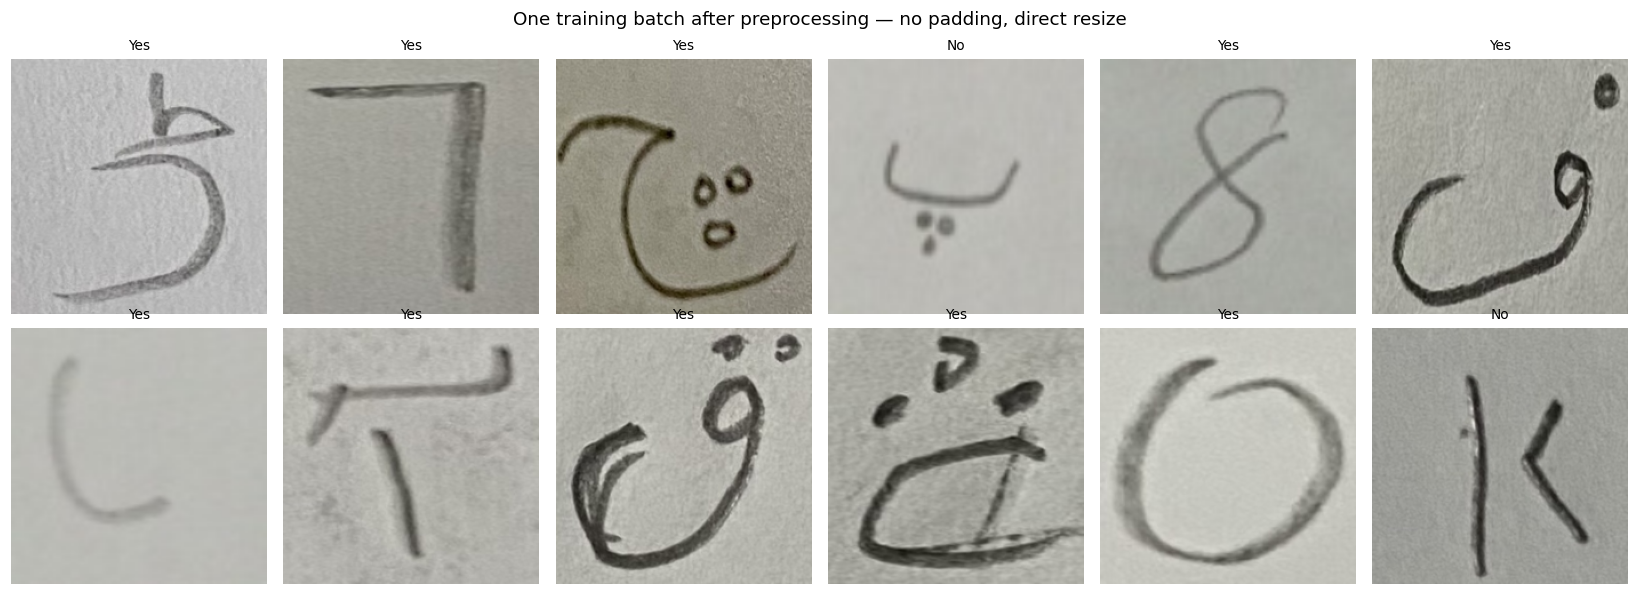

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_preprocessed_batch_nopad.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110


def denormalise(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Undo Normalize() for display. Inverse of (x - mean) / std."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)


fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for ax, im, lab in zip(axes.ravel(), images, labels):
    ax.imshow(denormalise(im))
    ax.set_title(IDX_TO_CLASS[int(lab)], fontsize=9)
    ax.axis('off')

fig.suptitle('One training batch after preprocessing — no padding, direct resize',
             fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'A_preprocessed_batch_nopad.png', bbox_inches='tight')
plt.show()
print(f'[saved] {FIGURES_DIR / "A_preprocessed_batch_nopad.png"}')

### 7.3 — The two pipelines side by side

This is the figure to show your supervisor. It puts the trade-off on one page: the same images,
padded above, direct-resized below, chosen from the most extreme aspect ratios in the dataset
where the difference is largest.

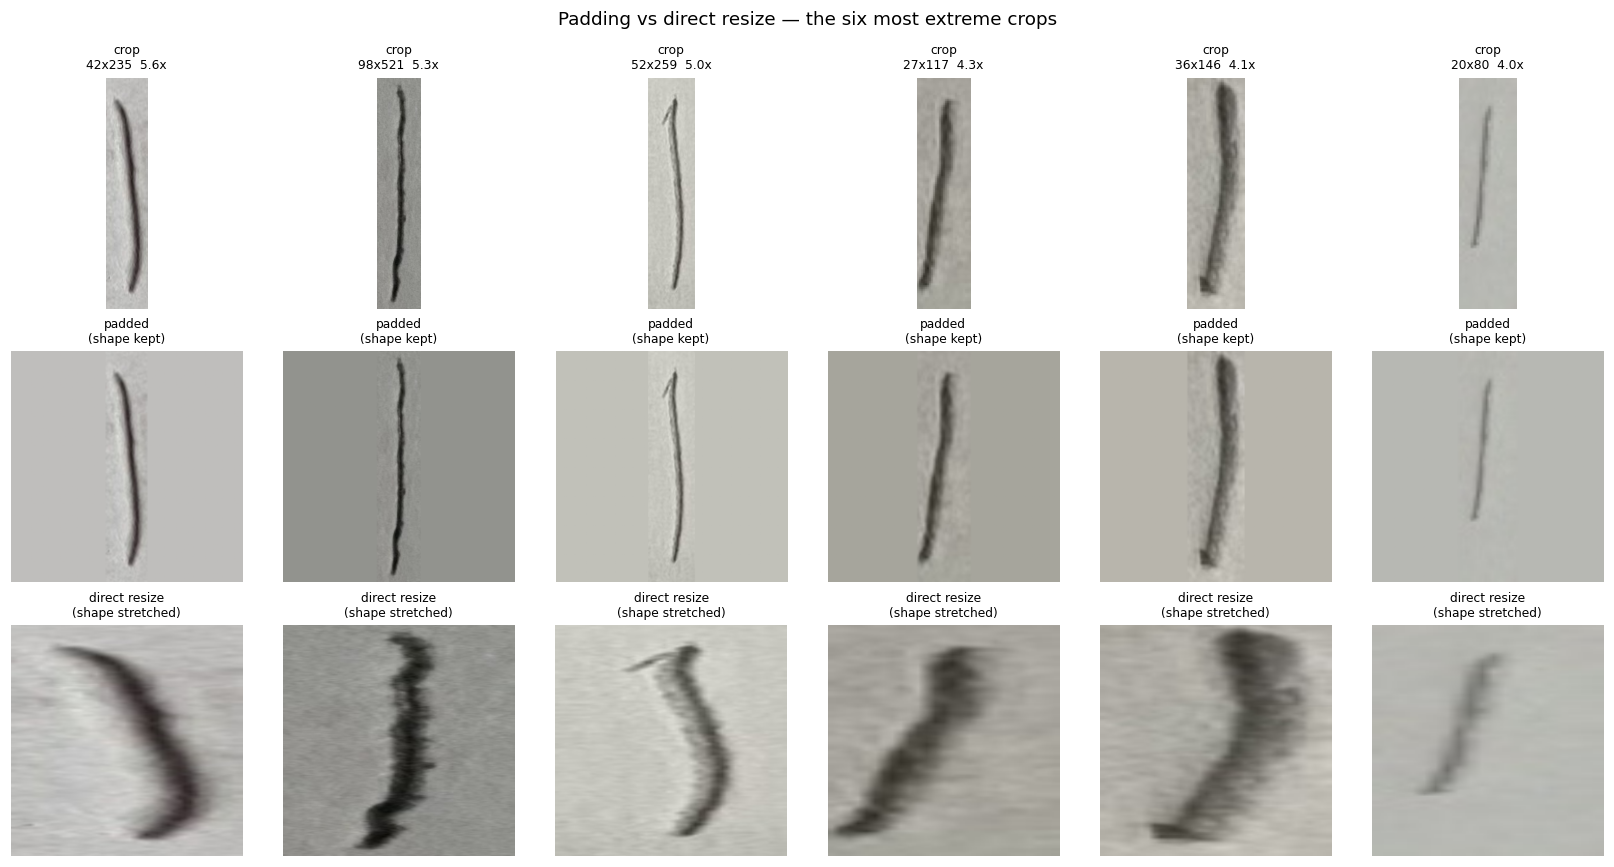

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_padding_vs_direct_resize.png


In [ ]:
_, pad_eval_tf   = build_transforms('padded')
_, nopad_eval_tf = build_transforms('no_padding')

extreme = splits[PRIMARY].nlargest(6, 'distortion')

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for col, (_, row) in enumerate(extreme.iterrows()):
    original = Image.open(row['abs_path']).convert('RGB')

    axes[0, col].imshow(original)
    axes[0, col].set_title(f'crop\n{row["crop_width"]}x{row["crop_height"]}  '
                           f'{row["distortion"]:.1f}x', fontsize=8)

    axes[1, col].imshow(denormalise(pad_eval_tf(original)))
    axes[1, col].set_title('padded\n(shape kept)', fontsize=8)

    axes[2, col].imshow(denormalise(nopad_eval_tf(original)))
    axes[2, col].set_title('direct resize\n(shape stretched)', fontsize=8)

    for r in range(3):
        axes[r, col].axis('off')

fig.suptitle('Padding vs direct resize — the six most extreme crops', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'A_padding_vs_direct_resize.png', bbox_inches='tight')
plt.show()
print(f'[saved] {FIGURES_DIR / "A_padding_vs_direct_resize.png"}')

**What to look for.** In the padded row the character keeps its proportions and sits inside a
blank margin. In the direct-resize row it fills the frame but is stretched.

For most images the difference is slight. For the extremes it is severe — and those extremes
are roughly 9% of the dataset. Whether that costs accuracy is an empirical question, which
Notebook 04 answers.

---
# STAGE 8 — Class Weights and the Baseline to Beat

A2_clean is imbalanced at roughly 2 Yes : 1 No. A model predicting `Yes` for everything would
score about 66% accuracy while being useless.

We compute inverse-frequency weights now and **do not apply them**. The rule is to measure the
problem before treating it — the baseline confusion matrix decides whether they are needed.

In [ ]:
def compute_class_weights(dataset) -> dict:
    """Inverse-frequency weights, from TRAINING data only."""
    counts = dataset.df['class_label'].value_counts()
    n_total, n_classes = len(dataset), len(CLASS_TO_IDX)
    return {cls: round(n_total / (n_classes * counts.get(cls, 1)), 4)
            for cls in CLASS_TO_IDX}


class_weights = compute_class_weights(datasets['train'])
print('training class counts :', datasets['train'].class_counts())
print('inverse-freq weights  :', class_weights)

majority = max(datasets['train'].class_counts().items(), key=lambda kv: kv[1])
maj_acc = 100 * majority[1] / len(datasets['train'])
print(f'\nMajority-class baseline: always predicting "{majority[0]}" scores {maj_acc:.1f}%.')
print('Any model must beat that, and because of the imbalance, accuracy alone')
print('will not be sufficient evidence that it has learned anything.')

training class counts : {'Yes': 284, 'No': 148}
inverse-freq weights  : {'No': np.float64(1.4595), 'Yes': np.float64(0.7606)}

Majority-class baseline: always predicting "Yes" scores 65.7%.
Any model must beat that, and because of the imbalance, accuracy alone
will not be sufficient evidence that it has learned anything.


---
# STAGE 9 — Save the Preprocessing Config

In [ ]:
preproc_config = {
    'created'            : datetime.now().isoformat(timespec='seconds'),
    'jira'               : 'DYS-17',
    'seed'               : SEED,
    'input_data'         : 'manually ROI-cropped (DYS-24/25/26)',
    'primary_split'      : PRIMARY,
    'img_size'           : IMG_SIZE,
    'preprocessing_mode' : PREPROC_MODE,
    'resize_strategy'    : 'direct resize to square, no padding',
    'padding'            : 'removed after supervisor review',
    'comparison_arm'     : 'padded (PadToSquare retained for controlled comparison)',
    'channels'           : 3,
    'normalisation'      : 'imagenet',
    'imagenet_mean'      : IMAGENET_MEAN,
    'imagenet_std'       : IMAGENET_STD,
    'dataset_mean'       : np.round(ds_mean, 4).tolist(),
    'dataset_std'        : np.round(ds_std, 4).tolist(),
    'augmentation'       : 'none',
    'batch_size'         : BATCH_SIZE,
    'num_workers'        : NUM_WORKERS,
    'class_to_idx'       : CLASS_TO_IDX,
    'class_weights'      : class_weights,
    'class_weights_applied': False,
    'majority_baseline'  : round(maj_acc / 100, 4),
    'distortion_median'  : round(float(d['distortion'].median()), 3),
    'distortion_max'     : round(float(d['distortion'].max()), 3),
    'pct_stretched_over_2x': round(float(100 * (d['distortion'] > 2).mean()), 2),
    'torch_version'      : torch.__version__,
    'torchvision_version': torchvision.__version__,
    'device'             : str(DEVICE),
}

CONFIG_PATH = EXPERIMENTS_DIR / 'preprocessing_config.json'
with open(CONFIG_PATH, 'w') as f:
    json.dump(preproc_config, f, indent=2)

print(json.dumps(preproc_config, indent=2))
print(f'\n[saved] {CONFIG_PATH}')

{
  "created": "2026-09-26T12:45:31",
  "jira": "DYS-17",
  "seed": 42,
  "input_data": "manually ROI-cropped (DYS-24/25/26)",
  "primary_split": "S1_clean",
  "img_size": 224,
  "preprocessing_mode": "no_padding",
  "resize_strategy": "direct resize to square, no padding",
  "padding": "removed after supervisor review",
  "comparison_arm": "padded (PadToSquare retained for controlled comparison)",
  "channels": 3,
  "normalisation": "imagenet",
  "imagenet_mean": [
    0.485,
    0.456,
    0.406
  ],
  "imagenet_std": [
    0.229,
    0.224,
    0.225
  ],
  "dataset_mean": [
    0.6313,
    0.6279,
    0.598
  ],
  "dataset_std": [
    0.1171,
    0.1188,
    0.1209
  ],
  "augmentation": "none",
  "batch_size": 32,
  "num_workers": 2,
  "class_to_idx": {
    "No": 0,
    "Yes": 1
  },
  "class_weights": {
    "No": 1.4595,
    "Yes": 0.7606
  },
  "class_weights_applied": false,
  "majority_baseline": 0.6574,
  "distortion_median": 1.319,
  "distortion_max": 5.595,
  "pct_stretched

---
# Experiment Log

## What we actually did

1. Removed padding from the preprocessing pipeline as directed, and resized directly to 224×224.
2. **Measured** the distortion that direct resizing applies, rather than assuming it is
   negligible.
3. Tested statistically whether distortion differs between classes, because if it did, the shape
   of the crop would become a class signal — the same category of artefact padding was removed
   to avoid.
4. Kept the padded pipeline implemented as a comparison arm, so the decision can be settled by
   experiment rather than by argument.
5. Rebuilt the Dataset and DataLoader to read from the cleaned split manifests.
6. Verified tensor shapes, value ranges and batch composition, and confirmed visually that the
   tensors reaching the model still contain handwriting.
7. Produced a three-row figure showing crop, padded and direct-resized versions of the six most
   extreme images.

## What we learned

**Cropping made aspect ratios more extreme, not less.** Blank margin used to moderate the shape
of the bounding box; without it the box follows the character. So the aspect range widened from
0.25–2.17 to 0.18–3.64, and direct resizing now distorts more than it would have before
cropping.

**Roughly 9% of images are stretched more than 2×**, with the worst above 5×. For most images
the difference between the two pipelines is slight; for those it is severe.

**The trade is real in both directions.** Padding adds learnable blank area; direct resize
distorts shape. Neither is free, and the honest resolution is a controlled experiment rather
than a preference.

## What we can tell

> We removed padding as directed and measured what replaced it. Manual cropping tightened the
> bounding boxes, which made aspect ratios more extreme, so direct resizing stretches about 9%
> of images by more than a factor of two. We have implemented both pipelines and will report a
> controlled comparison — identical model, seed and hyperparameters, one factor changed — so the
> choice rests on a measured difference rather than on either of our assumptions.

## Limitations carried forward

| Limitation | Effect |
|---|---|
| Direct resize distorts extreme aspect ratios | Character shape is altered for ~9% of images |
| Aspect ratio could act as a class signal | Tested at distribution level only; not ruled out per image |
| ~2:1 class imbalance | Accuracy alone is misleading; per-class metrics required |
| ~430 training images | Overfitting likely; results will vary between seeds |
| Manual cropping is subjective | Two people drew the ROIs; consistency between them is unmeasured |

That last one is new and worth stating. The crops were produced by two team members working on
different classes. If one cropped systematically tighter than the other, that difference aligns
exactly with the class boundary. It is not currently measured.

---